In [10]:
!pip install langchain-experimental
!pip install tabulate

In [1]:
def warn(*agrs , **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings("ignore")
from groq import Groq
from langchain_groq import ChatGroq
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#Loading the dataset
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/ZNoKMJ9rssJn-QbJ49kOzA/student-mat.csv"
)

In [3]:
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [4]:
api_key = "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"
llm = ChatGroq(
    model = "llama-3.3-70b-versatile",
    groq_api_key = api_key,
    temperature = 0,
    max_tokens = 256
)
agent = create_pandas_dataframe_agent(
    llm,
    df,
    verbose = False,
    return_intermediate_steps = True,
    allow_dangerous_code = True
)


In [6]:
response = agent.invoke("How many rows are there in the dataframe?.")
response["output"]

'There are 395 rows in the dataframe.'

In [7]:
len(df)

395

In [9]:
response = agent.invoke("Give me all the data where student's age is over 18 years old?.")
print(response)

{'input': "Give me all the data where student's age is over 18 years old?.", 'output': "df[df['age'] > 18]", 'intermediate_steps': [(AgentAction(tool='python_repl_ast', tool_input="df[df['age'] > 18]\n", log="Thought: To get all the data where the student's age is over 18 years old, I need to filter the dataframe based on the 'age' column.\n\nAction: python_repl_ast\nAction Input: df[df['age'] > 18]\n"),     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
127     GP   F   19       U     GT3       T     0     1   at_home     other   
153     GP   M   19       U     GT3       T     3     2  services   at_home   
210     GP   F   19       U     GT3       T     3     3     other     other   
247     GP   M   22       U     GT3       T     3     1  services  services   
257     GP   M   19       U     LE3       A     4     3  services   at_home   
270     GP   F   19       U     GT3       T     3     3     other  services   
296     GP   F   19       U     GT3    

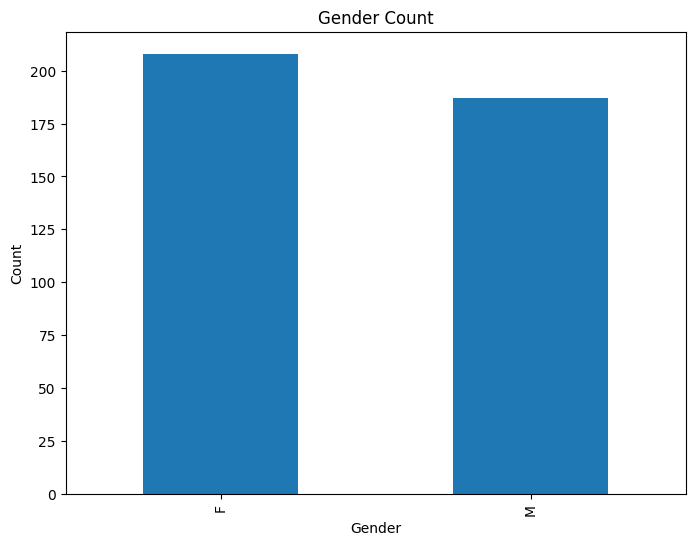

{'input': 'Generate a bar chart to plot data in gender count',
 'output': 'The bar chart to plot data in gender count has been generated. The chart shows that there are 208 females and 187 males in the dataframe.',
 'intermediate_steps': [(AgentAction(tool='python_repl_ast', tool_input="```python\nimport matplotlib.pyplot as plt\ngender_counts = df['sex'].value_counts()\nprint(gender_counts)\n```", log="Thought: To generate a bar chart to plot data in gender count, we first need to count the number of males and females in the dataframe. We can use the pandas `value_counts` function to achieve this.\n\nAction: python_repl_ast\nAction Input:\n```python\nimport matplotlib.pyplot as plt\ngender_counts = df['sex'].value_counts()\nprint(gender_counts)\n```"),
   'sex\nF    208\nM    187\nName: count, dtype: int64\n'),
  (AgentAction(tool='python_repl_ast', tool_input="```python\nimport matplotlib.pyplot as plt\ngender_counts = df['sex'].value_counts()\nplt.figure(figsize=(8,6))\ngender_count

In [10]:
response = agent.invoke("Generate a bar chart to plot data in gender count")
response

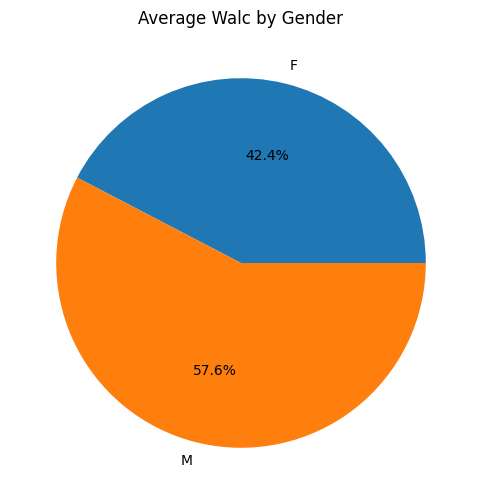

{'input': 'Generate a pi chart to display average value of walc for each gender?.',
 'output': "The provided code will generate a pie chart displaying the average 'Walc' for each gender.",
 'intermediate_steps': [(AgentAction(tool='python_repl_ast', tool_input="```python\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n# Calculate the average 'Walc' for each gender\naverage_walc = df.groupby('sex')['Walc'].mean()\n\nprint(average_walc)\n```", log="Thought: To generate a pie chart to display the average value of 'Walc' for each gender, we first need to calculate the average 'Walc' for each gender. We can use the pandas library to group the data by 'sex' and calculate the mean of 'Walc' for each group.\n\nAction: python_repl_ast\nAction Input:\n```python\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n# Calculate the average 'Walc' for each gender\naverage_walc = df.groupby('sex')['Walc'].mean()\n\nprint(average_walc)\n```"),
   'sex\nF    1.956731\nM    2.663102\nName: 

In [11]:
response = agent.invoke("Generate a pi chart to display average value of walc for each gender?.")
response

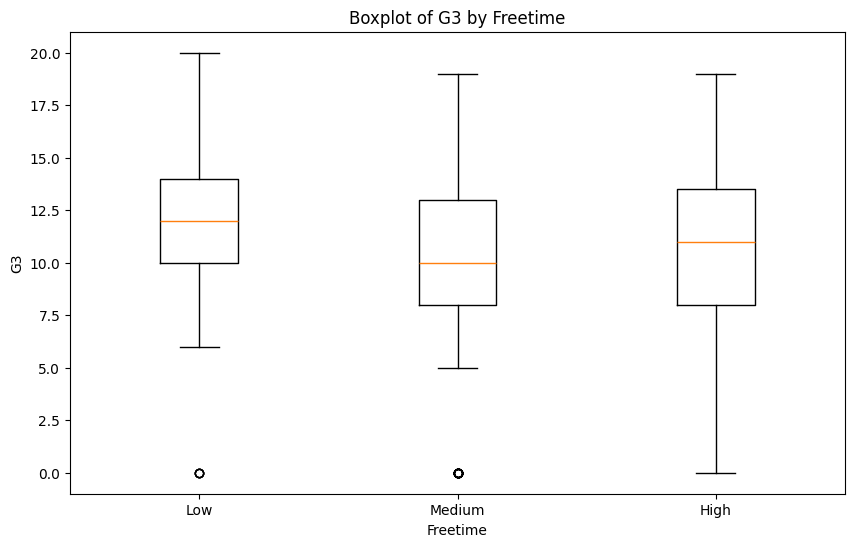

In [12]:
response = agent.invoke("Create box plots to analyze the relationship between 'freetime' (amount of free time) and 'G3' (final grade) across different levels of free time.")

In [13]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

```python
print(df.groupby('freetime')['G3'].describe())
```


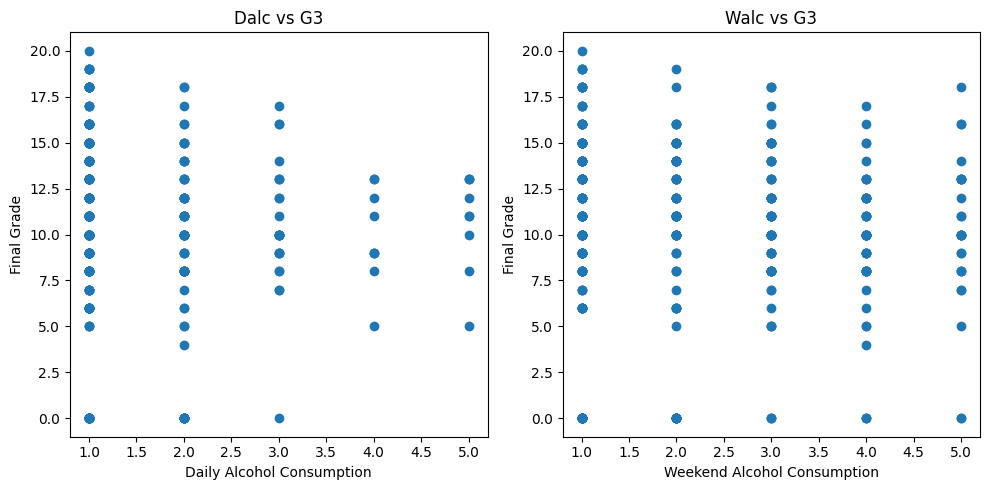

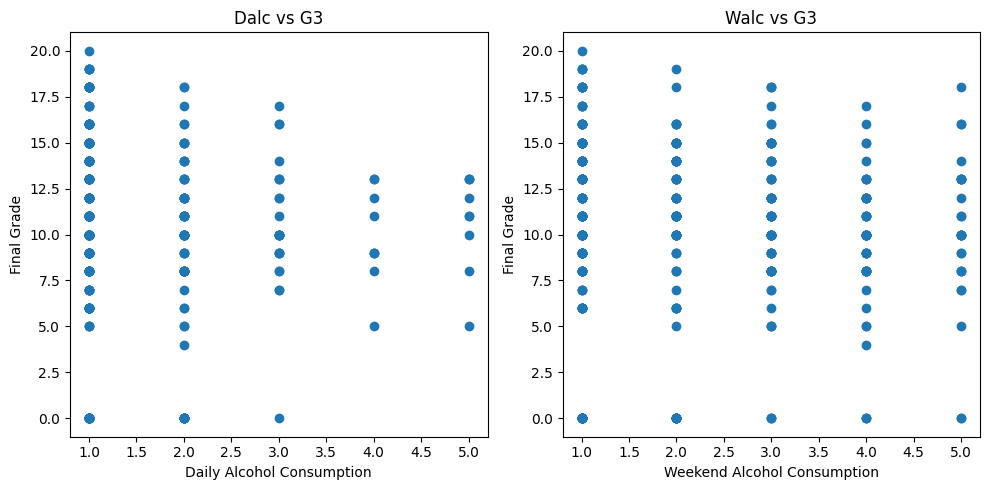

In [14]:
response = agent.invoke("Generate scatter plots to examine the correlation between 'Dalc' (daily alcohol consumption) and 'G3', and between 'Walc' (weekend alcohol consumption) and 'G3'.")

In [15]:
print(response['intermediate_steps'][-1][0].tool_input.replace('; ', '\n'))

```python
import matplotlib.pyplot as plt
import pandas as pd

# Assuming df is the DataFrame
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(df['Dalc'], df['G3'])
plt.xlabel('Daily Alcohol Consumption')
plt.ylabel('Final Grade')
plt.title('Dalc vs G3')

plt.subplot(1,2,2)
plt.scatter(df['Walc'], df['G3'])
plt.xlabel('Weekend Alcohol Consumption')
plt.ylabel('Final Grade')
plt.title('Walc vs G3')

plt.tight_layout()
plt.show()
```
